# Deteccao de Anomalias em Turbinas Eolicas com CNN-LSTM Autoencoder
## Wind Farm C -- Dados SCADA

Pipeline completo para deteccao de anomalias em turbinas eolicas offshore utilizando
dados SCADA com resolucao de 10 minutos. O fluxo inclui pre-processamento, selecao
de features via XGBoost, treinamento de um autoencoder CNN-LSTM em PyTorch e avaliacao
quantitativa da deteccao de falhas.

In [ ]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

BASE_DIR = os.path.join('CARE_To_Compare', 'Wind Farm C')
DATASETS_DIR = os.path.join(BASE_DIR, 'datasets')
EVENT_INFO_PATH = os.path.join(BASE_DIR, 'event_info.csv')
FEATURE_DESC_PATH = os.path.join(BASE_DIR, 'feature_description.csv')
OUTPUT_DIR = 'artefatos'
os.makedirs(OUTPUT_DIR, exist_ok=True)

WINDOW_SIZE = 36
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
FEATURE_TOP_PERCENT = 0.30
BATCH_SIZE = 32
EPOCHS = 10
PATIENCE = 5
LEARNING_RATE = 1e-3

META_COLS = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id']
HEALTHY_STATUS = [0, 2]

print(f"Janela temporal: {WINDOW_SIZE} steps ({WINDOW_SIZE * 10 / 60:.0f} horas)")
print(f"Split: {TRAIN_RATIO*100:.0f}% treino / {VAL_RATIO*100:.0f}% validacao / {TEST_RATIO*100:.0f}% teste")
print(f"Selecao de features: top {FEATURE_TOP_PERCENT*100:.0f}% (XGBoost)")

Dispositivo: cuda
Janela temporal: 36 steps (6 horas)
Split: 70% treino / 15% validacao / 15% teste
Selecao de features: top 30% (XGBoost)


## 1. Carregamento dos Dados

Carregamento de todos os 58 datasets CSV do Wind Farm C e do arquivo de informacoes
de eventos. Cada dataset contem series temporais SCADA de uma turbina com resolucao
de 10 minutos e ate 957 features (sensores com estatisticas avg, min, max, std).

In [2]:
event_info = pd.read_csv(EVENT_INFO_PATH, sep=';')
event_info['event_start'] = pd.to_datetime(event_info['event_start'])
event_info['event_end'] = pd.to_datetime(event_info['event_end'])

print(f"Total de eventos: {len(event_info)}")
print(f"  Anomalias: {(event_info['event_label'] == 'anomaly').sum()}")
print(f"  Normais:   {(event_info['event_label'] == 'normal').sum()}")
print(f"  Turbinas unicas: {event_info['asset_id'].nunique()}")
event_info.head(10)

Total de eventos: 58
  Anomalias: 27
  Normais:   31
  Turbinas unicas: 22


,asset_id,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,50,55,anomaly,2023-10-29 11:30:00,52848,2023-11-15 15:30:00,55320,Harting plug Nacelle/HUB damaged + NCR20_HUB: ...
1,38,81,anomaly,2023-11-16 01:30:00,52704,2023-11-18 14:00:00,53067,Converter Failure from 17.11 12:30 - 18.11. 13...
2,21,47,anomaly,2023-12-22 15:00:00,52416,2023-12-27 13:40:00,53128,Failure due to Rotorbrake and Hydraulic proble...
3,2,12,anomaly,2023-06-27 00:00:00,52560,2023-07-19 15:00:00,55818,"10115 : Oil level error, two-pump mode + Oil L..."
4,34,4,anomaly,2023-07-31 10:00:00,52992,2023-08-19 10:00:00,55728,23020 : Axis 3 not ready-to-operate
5,34,18,anomaly,2023-09-13 00:00:00,51408,2023-09-16 23:50:00,51983,We had some failures (störung 24VAC Versorgung...
6,52,28,anomaly,2023-05-28 13:00:00,52704,2023-06-17 20:30:00,55629,P20_spinner_carbonbrush defekt + P20_Accumulat...
7,52,39,anomaly,2023-10-19 13:00:00,52848,2023-10-24 15:20:00,53582,15004 : Safety chain relay open + 93005 : Gear...
8,12,66,anomaly,2023-01-17 00:00:00,51696,2023-01-23 13:00:00,52638,"Pitchfailure - defect Beckhoffcard, Axis 2, re..."
9,12,15,anomaly,2023-02-06 00:00:00,51984,2023-02-23 00:00:00,54432,Randomn small failures regarding pitch resulti...


In [3]:
import gc
import time as _time

def _dbg(loc, msg, data=None):  # region agent log
    import json as _j
    with open('debug-d7fb79.log', 'a') as _f:
        _f.write(_j.dumps({"sessionId":"d7fb79","location":loc,"message":msg,"data":data or {},"timestamp":int(_time.time()*1000),"hypothesisId":"A"}) + "\n")
# endregion

csv_files = sorted([f for f in os.listdir(DATASETS_DIR) if f.endswith('.csv')])
print(f"Total de arquivos CSV: {len(csv_files)}")

# ---------------------------------------------------------------------------
# Passo 1 (leve): coletar todos os timestamps para definir cortes temporais
# ---------------------------------------------------------------------------
print("Passo 1: coletando timestamps para definir cortes do split temporal...")
all_ts = []
for csv_file in csv_files:
    ts = pd.read_csv(os.path.join(DATASETS_DIR, csv_file),
                     sep=';', usecols=['time_stamp'])['time_stamp']
    all_ts.append(pd.to_datetime(ts))

all_ts = pd.concat(all_ts).sort_values().reset_index(drop=True)
n_total = len(all_ts)
ts_train_cutoff = all_ts.iloc[int(n_total * TRAIN_RATIO)]
ts_val_cutoff   = all_ts.iloc[int(n_total * (TRAIN_RATIO + VAL_RATIO))]
del all_ts; gc.collect()

print(f"  Amostras totais: {n_total:,}")
print(f"  Corte treino/val: {ts_train_cutoff}")
print(f"  Corte val/teste:  {ts_val_cutoff}")

# ---------------------------------------------------------------------------
# Passo 2: carregar cada arquivo, ffill, labeling e split -- um de cada vez
# ---------------------------------------------------------------------------
# Read numeric cols as float32 from the start to avoid MemoryError during astype
sample_header = pd.read_csv(os.path.join(DATASETS_DIR, csv_files[0]), sep=';', nrows=0)
scols_all = [c for c in sample_header.columns if c not in META_COLS]
dtype_map = {c: np.float32 for c in scols_all}

print("\nPasso 2: processamento por arquivo (ffill + labeling + split)...")
anomaly_dict = {}
for _, row in event_info[event_info['event_label'] == 'anomaly'].iterrows():
    anomaly_dict[row['event_id']] = (row['event_start'], row['event_end'])

train_parts, val_parts, test_parts = [], [], []

for i, csv_file in enumerate(csv_files):
    event_id = int(csv_file.replace('.csv', ''))
    filepath = os.path.join(DATASETS_DIR, csv_file)

    df = pd.read_csv(filepath, sep=';', dtype=dtype_map)
    df['event_id'] = event_id
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])

    scols = [c for c in df.columns if c not in META_COLS + ['event_id']]
    df[scols] = df[scols].ffill()
    df[scols] = df[scols].bfill()

    # Labeling
    df['label'] = 0
    if event_id in anomaly_dict:
        es, ee = anomaly_dict[event_id]
        mask_anom = (df['time_stamp'] >= es) & (df['time_stamp'] <= ee)
        df.loc[mask_anom, 'label'] = 1

    df['is_healthy'] = (
        (df['label'] == 0) & df['status_type_id'].isin(HEALTHY_STATUS)
    ).astype(np.int8)

    # Split temporal
    m_tr = df['time_stamp'] < ts_train_cutoff
    m_va = (df['time_stamp'] >= ts_train_cutoff) & (df['time_stamp'] < ts_val_cutoff)
    m_te = df['time_stamp'] >= ts_val_cutoff

    if m_tr.any(): train_parts.append(df.loc[m_tr])
    if m_va.any(): val_parts.append(df.loc[m_va])
    if m_te.any(): test_parts.append(df.loc[m_te])

    del df
    if (i + 1) % 10 == 0:
        gc.collect()
    if (i + 1) % 20 == 0 or (i + 1) == len(csv_files):
        print(f"  Processados: {i + 1}/{len(csv_files)}")
        _dbg("cell4:proc", f"processed {i+1}", {"n": i+1})  # region agent log  # endregion

# ---------------------------------------------------------------------------
# Concatenar e ordenar cada split separadamente (economia de memoria)
# ---------------------------------------------------------------------------
print("\nConcatenando e ordenando splits...")

df_train = pd.concat(train_parts, ignore_index=True)
del train_parts; gc.collect()
df_train.sort_values('time_stamp', inplace=True)
df_train.reset_index(drop=True, inplace=True)

df_val = pd.concat(val_parts, ignore_index=True)
del val_parts; gc.collect()
df_val.sort_values('time_stamp', inplace=True)
df_val.reset_index(drop=True, inplace=True)

df_test = pd.concat(test_parts, ignore_index=True)
del test_parts; gc.collect()
df_test.sort_values('time_stamp', inplace=True)
df_test.reset_index(drop=True, inplace=True)

n = len(df_train) + len(df_val) + len(df_test)
for name, sp in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    ns = len(sp)
    mem = sp.memory_usage(deep=True).sum() / 1e6
    print(f"  {name:10s}: {ns:>7,} amostras ({ns/n*100:5.1f}%) | "
          f"Anomalias: {(sp['label']==1).sum():>5,} | "
          f"Saudaveis: {(sp['is_healthy']==1).sum():>7,} | "
          f"Mem: {mem:,.0f} MB")

_dbg("cell4:done", "splits ready", {
    "train": list(df_train.shape), "val": list(df_val.shape),
    "test": list(df_test.shape)})  # region agent log  # endregion

Total de arquivos CSV: 58
Passo 1: coletando timestamps para definir cortes do split temporal...
  Amostras totais: 3,187,136
  Corte treino/val: 2023-04-15 11:40:00
  Corte val/teste:  2023-07-08 20:10:00

Passo 2: processamento por arquivo (ffill + labeling + split)...
  Processados: 20/58
  Processados: 40/58
  Processados: 58/58

Concatenando e ordenando splits...
  Treino    : 2,230,956 amostras ( 70.0%) | Anomalias: 14,133 | Saudaveis: 1,994,546 | Mem: 8,725 MB
  Validacao : 478,082 amostras ( 15.0%) | Anomalias: 4,631 | Saudaveis: 414,795 | Mem: 1,870 MB
  Teste     : 478,098 amostras ( 15.0%) | Anomalias: 42,133 | Saudaveis: 386,050 | Mem: 1,870 MB


## 2. Rotulacao (Labeling)

Criacao de labels binarios para cada amostra:
- **0 (saudavel)**: timestamp fora de qualquer periodo de anomalia
- **1 (anomalia)**: timestamp dentro do periodo `[event_start, event_end]` de um evento
  classificado como anomalia no `event_info.csv`

Adicionalmente, definimos o conceito de amostra **estritamente saudavel** como aquela
com `label=0` e `status_type_id` em {0 (operacao normal), 2 (idling)}. Somente estas
amostras serao usadas para treinar o autoencoder, garantindo que o modelo aprenda
exclusivamente o comportamento normal da turbina.

In [4]:
all_labels = pd.concat([df_train['label'], df_val['label'], df_test['label']])
all_healthy = pd.concat([df_train['is_healthy'], df_val['is_healthy'], df_test['is_healthy']])
all_status = pd.concat([df_train['status_type_id'], df_val['status_type_id'], df_test['status_type_id']])

print("Distribuicao de labels (todos os splits combinados):")
print(f"  Saudavel (0):  {(all_labels == 0).sum():,} "
      f"({(all_labels == 0).mean()*100:.1f}%)")
print(f"  Anomalia (1):  {(all_labels == 1).sum():,} "
      f"({(all_labels == 1).mean()*100:.1f}%)")
print(f"\nAmostras estritamente saudaveis (label=0 e status normal/idling): "
      f"{(all_healthy == 1).sum():,} ({(all_healthy == 1).mean()*100:.1f}%)")
print(f"\nDistribuicao de status_type_id:")
print(all_status.value_counts().sort_index().to_string())
del all_labels, all_healthy, all_status

Distribuicao de labels (todos os splits combinados):
  Saudavel (0):  3,126,239 (98.1%)
  Anomalia (1):  60,897 (1.9%)

Amostras estritamente saudaveis (label=0 e status normal/idling): 2,795,391 (87.7%)

Distribuicao de status_type_id:
status_type_id
0    2843548
3     246764
4      20036
5      76788


## 3. Divisao Temporal dos Dados

Divisao estritamente temporal (70% treino / 15% validacao / 15% teste) baseada na
ordenacao global por timestamp. Em series temporais, a divisao aleatoria e proibida
pois causa vazamento de informacao temporal (data leakage).

O scaler e o XGBoost serao ajustados **somente** nos dados de treino.

In [5]:
n = len(df_train) + len(df_val) + len(df_test)

print("Verificacao da divisao temporal (ja realizada na etapa de carregamento):\n")
for name, split in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    n_total = len(split)
    n_anom = (split['label'] == 1).sum()
    n_healthy = (split['is_healthy'] == 1).sum()
    print(f"{name:10s}: {n_total:>7,} amostras ({n_total/n*100:5.1f}%) | "
          f"Anomalias: {n_anom:>5,} | Saudaveis: {n_healthy:>7,} | "
          f"Periodo: {split['time_stamp'].min()} -- {split['time_stamp'].max()}")

print(f"\nCorte treino/val: {ts_train_cutoff}")
print(f"Corte val/teste:  {ts_val_cutoff}")

Verificacao da divisao temporal (ja realizada na etapa de carregamento):

Treino    : 2,230,956 amostras ( 70.0%) | Anomalias: 14,133 | Saudaveis: 1,994,546 | Periodo: 2022-01-06 00:00:00 -- 2023-04-15 11:30:00
Validacao : 478,082 amostras ( 15.0%) | Anomalias: 4,631 | Saudaveis: 414,795 | Periodo: 2023-04-15 11:40:00 -- 2023-07-08 20:00:00
Teste     : 478,098 amostras ( 15.0%) | Anomalias: 42,133 | Saudaveis: 386,050 | Periodo: 2023-07-08 20:10:00 -- 2024-01-08 15:40:00

Corte treino/val: 2023-04-15 11:40:00
Corte val/teste:  2023-07-08 20:10:00


## 4. Normalizacao dos Dados

Normalizacao Min-Max para o intervalo [0, 1] aplicada a todas as features de sensores.
O scaler e ajustado **exclusivamente** nos dados de treino para evitar vazamento de
informacao (data leakage). Os conjuntos de validacao e teste sao transformados com
os parametros aprendidos no treino.

In [6]:
sensor_cols = [c for c in df_train.columns
              if c not in META_COLS + ['event_id', 'label', 'is_healthy']]
print(f"Total de features de sensores: {len(sensor_cols)}")

scaler = MinMaxScaler(feature_range=(0, 1))
CHUNK_FIT = 50_000
for start in range(0, len(df_train), CHUNK_FIT):
    end = min(start + CHUNK_FIT, len(df_train))
    scaler.partial_fit(df_train[sensor_cols].iloc[start:end])

print("Scaler ajustado via partial_fit (sem converter tudo para float64)")

scale_ = scaler.scale_.astype(np.float32)
min_   = scaler.min_.astype(np.float32)

for split_name, df_split in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    for i, col in enumerate(sensor_cols):
        vals = df_split[col].values * scale_[i] + min_[i]
        np.clip(vals, 0, 1, out=vals)
        df_split[col] = vals
    gc.collect()
    print(f"  {split_name} normalizado")

del scale_, min_; gc.collect()

print("\nNormalizacao concluida (MinMaxScaler ajustado somente no treino)")
for name, split in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    vals = split[sensor_cols]
    print(f"  {name:10s} - min: {vals.min().min():.4f}, "
          f"max: {vals.max().max():.4f}, media: {vals.mean().mean():.4f}")

Total de features de sensores: 952
Scaler ajustado via partial_fit (sem converter tudo para float64)
  Treino normalizado
  Validacao normalizado
  Teste normalizado

Normalizacao concluida (MinMaxScaler ajustado somente no treino)
  Treino     - min: 0.0000, max: 1.0000, media: 0.4021
  Validacao  - min: 0.0000, max: 1.0000, media: 0.3921
  Teste      - min: 0.0000, max: 1.0000, media: 0.4034


## 5. Selecao de Features com XGBoost

Utilizacao do XGBoost para classificacao binaria (saudavel vs anomalia) nos dados de
treino. As features sao rankeadas por importancia (`feature_importances_`) e as top
30% sao selecionadas, reduzindo a dimensionalidade e mantendo as variaveis mais
relevantes para a deteccao de falhas.

O XGBoost e ajustado **somente** nos dados de treino.

In [7]:
MAX_XGB_SAMPLES = 200_000
if len(df_train) > MAX_XGB_SAMPLES:
    rng = np.random.RandomState(SEED)
    sample_idx = rng.choice(len(df_train), MAX_XGB_SAMPLES, replace=False)
    sample_idx.sort()
    X_train_xgb = df_train[sensor_cols].iloc[sample_idx].values
    y_train_xgb = df_train['label'].iloc[sample_idx].values
    print(f"Subamostra para XGBoost: {MAX_XGB_SAMPLES:,} de {len(df_train):,}")
else:
    X_train_xgb = df_train[sensor_cols].values
    y_train_xgb = df_train['label'].values

print(f"Treinando XGBoost: {X_train_xgb.shape[0]:,} amostras, {X_train_xgb.shape[1]} features")
print(f"  Classes: 0={int((y_train_xgb == 0).sum()):,}  1={int((y_train_xgb == 1).sum()):,}")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=SEED,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_xgb, y_train_xgb)

importances = xgb_model.feature_importances_.copy()
feature_importance_df = pd.DataFrame({
    'feature': sensor_cols,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

n_selected = max(1, int(len(sensor_cols) * FEATURE_TOP_PERCENT))
selected_features = feature_importance_df.head(n_selected)['feature'].tolist()

print(f"\nFeatures originais: {len(sensor_cols)}")
print(f"Features selecionadas (top {FEATURE_TOP_PERCENT*100:.0f}%): {n_selected}")
print(f"\nTop 20 features mais importantes:")
print(feature_importance_df.head(20).to_string())

del X_train_xgb, y_train_xgb, xgb_model; gc.collect()

Subamostra para XGBoost: 200,000 de 2,230,956
Treinando XGBoost: 200,000 amostras, 952 features
  Classes: 0=198,756  1=1,244

Features originais: 952
Features selecionadas (top 30%): 285

Top 20 features mais importantes:
           feature  importance
0   sensor_227_min    0.238318
1   sensor_225_max    0.081889
2   sensor_232_avg    0.072621
3   sensor_126_avg    0.055897
4   sensor_210_min    0.052633
5    sensor_64_min    0.016566
6    sensor_72_avg    0.015892
7    sensor_45_min    0.014056
8    sensor_44_min    0.011524
9    sensor_66_avg    0.010540
10   sensor_62_max    0.010333
11  sensor_196_max    0.010018
12   sensor_44_avg    0.009366
13   sensor_61_max    0.009029
14  sensor_217_min    0.008004
15  sensor_203_min    0.007762
16   sensor_12_std    0.007503
17   sensor_41_max    0.007101
18   sensor_14_min    0.006854
19  sensor_225_min    0.005808


40

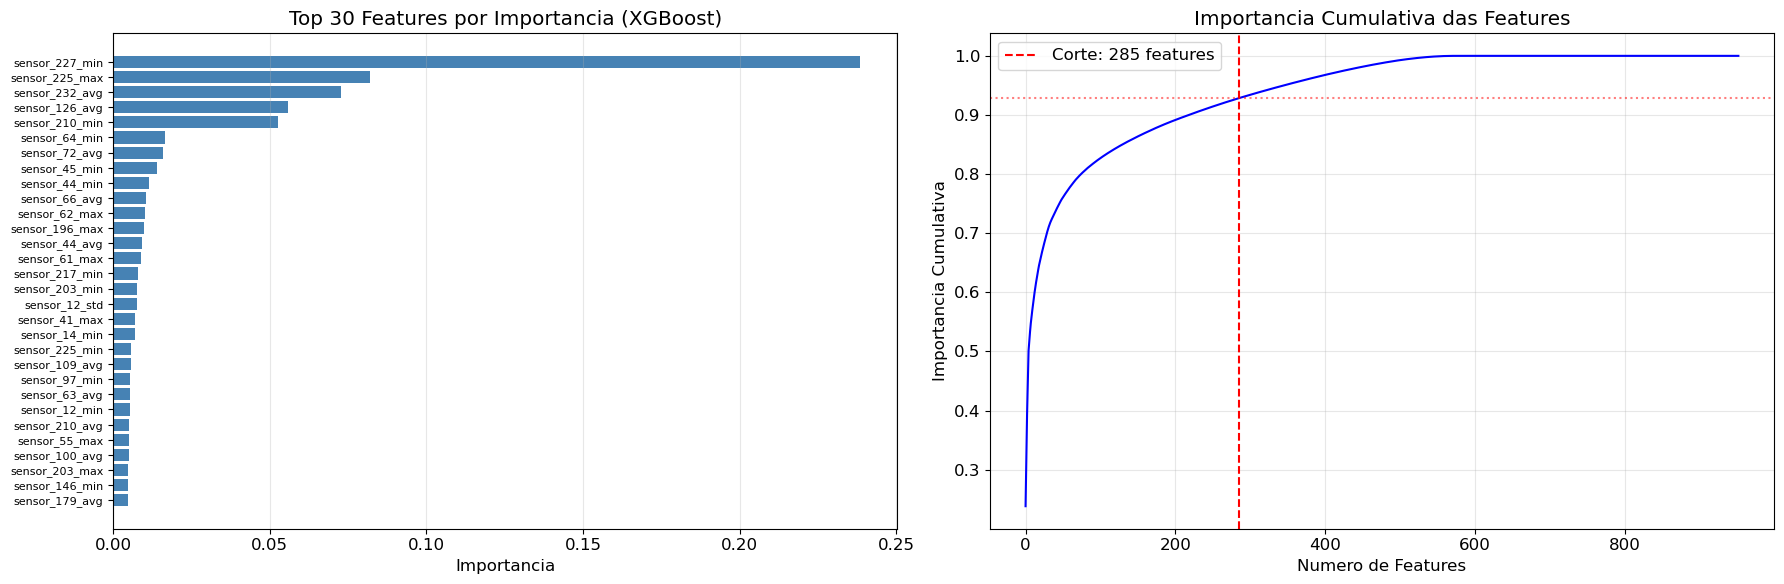

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_n = min(30, n_selected)
top_features = feature_importance_df.head(top_n)
axes[0].barh(range(top_n), top_features['importance'].values[::-1], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_features['feature'].values[::-1], fontsize=8)
axes[0].set_xlabel('Importancia')
axes[0].set_title(f'Top {top_n} Features por Importancia (XGBoost)')
axes[0].grid(True, alpha=0.3, axis='x')

sorted_imp = np.sort(importances)[::-1]
cumulative = np.cumsum(sorted_imp) / sorted_imp.sum()
axes[1].plot(range(len(cumulative)), cumulative, 'b-', linewidth=1.5)
axes[1].axvline(x=n_selected, color='r', linestyle='--',
                label=f'Corte: {n_selected} features')
axes[1].axhline(y=cumulative[n_selected - 1], color='r', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Numero de Features')
axes[1].set_ylabel('Importancia Cumulativa')
axes[1].set_title('Importancia Cumulativa das Features')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
keep_cols = ['time_stamp', 'event_id', 'label', 'is_healthy']
df_train_sel = df_train[keep_cols + selected_features].copy()
df_val_sel = df_val[keep_cols + selected_features].copy()
df_test_sel = df_test[keep_cols + selected_features].copy()

del df_train, df_val, df_test
gc.collect()

print("Dimensao apos selecao de features:")
print(f"  Treino:    {df_train_sel.shape}")
print(f"  Validacao: {df_val_sel.shape}")
print(f"  Teste:     {df_test_sel.shape}")

Dimensao apos selecao de features:
  Treino:    (2230956, 289)
  Validacao: (478082, 289)
  Teste:     (478098, 289)


## 6. Criacao de Janelas Temporais

Criacao de janelas deslizantes de 36 timesteps (equivalente a 6 horas com dados de
10 em 10 minutos). As janelas sao construidas **dentro de cada dataset** (mesmo
`event_id`) para nao misturar dados de diferentes turbinas ou eventos.

- **Janela saudavel**: todos os 36 timesteps possuem `is_healthy=1`
- **Janela com anomalia**: pelo menos 1 timestep possui `label=1`

In [10]:
def build_window_index(df, window_size, feature_cols):
    """Build per-group flat arrays and window metadata without materializing windows.

    Instead of storing an (N, W, F) tensor (~91 GB for training), we keep the
    flat feature arrays per event_id and a compact index of (eid, start, label,
    healthy) per window.  Windows are constructed on-the-fly in WindowDataset.
    """
    group_arrays = {}
    all_eid, all_start, all_label, all_healthy = [], [], [], []

    for eid, group in df.groupby('event_id'):
        group = group.sort_values('time_stamp').reset_index(drop=True)
        group_arrays[eid] = group[feature_cols].values.astype(np.float32)
        labels  = group['label'].values.astype(np.int8)
        healthy = group['is_healthy'].values.astype(np.int8)

        n = len(group)
        if n < window_size:
            continue

        nw = n - window_size + 1
        cum_l = np.concatenate([[0], np.cumsum(labels)])
        cum_h = np.concatenate([[0], np.cumsum(healthy)])
        w_labels  = (cum_l[window_size:] - cum_l[:nw] > 0).astype(np.int8)
        w_healthy = (cum_h[window_size:] - cum_h[:nw] == window_size).astype(np.int8)

        all_eid.append(np.full(nw, eid, dtype=np.int32))
        all_start.append(np.arange(nw, dtype=np.int32))
        all_label.append(w_labels)
        all_healthy.append(w_healthy)

    return (group_arrays,
            np.concatenate(all_eid),
            np.concatenate(all_start),
            np.concatenate(all_label),
            np.concatenate(all_healthy))


class WindowDataset(torch.utils.data.Dataset):
    """Memory-efficient dataset: builds each window on-the-fly from flat arrays."""
    def __init__(self, group_arrays, eids, starts, window_size):
        self.ga     = group_arrays
        self.eids   = eids
        self.starts = starts
        self.ws     = window_size

    def __len__(self):
        return len(self.eids)

    def __getitem__(self, idx):
        e = int(self.eids[idx])
        s = int(self.starts[idx])
        return torch.from_numpy(self.ga[e][s:s + self.ws].copy())


ga_train, eid_tr, start_tr, y_train, h_train = build_window_index(
    df_train_sel, WINDOW_SIZE, selected_features)
del df_train_sel; gc.collect()

ga_val, eid_va, start_va, y_val, h_val = build_window_index(
    df_val_sel, WINDOW_SIZE, selected_features)
del df_val_sel; gc.collect()

ga_test, eid_te, start_te, y_test, h_test = build_window_index(
    df_test_sel, WINDOW_SIZE, selected_features)
del df_test_sel; gc.collect()

n_features = len(selected_features)
print(f"Indices de janelas criados (window_size={WINDOW_SIZE}, features={n_features}):")
for name, eid_arr, y_arr, h_arr in [
    ('Treino', eid_tr, y_train, h_train),
    ('Validacao', eid_va, y_val, h_val),
    ('Teste', eid_te, y_test, h_test)]:
    print(f"  {name:10s}: {len(eid_arr):>7,} janelas | "
          f"Anomalias: {y_arr.sum():,} | Saudaveis: {h_arr.sum():,}")

ga_mem = sum(a.nbytes for a in ga_train.values()) / 1e9
print(f"\nMemoria: ~{ga_mem:.1f} GB (treino) vs ~{ga_mem * WINDOW_SIZE:.0f} GB "
      f"se janelas fossem materializadas")

Indices de janelas criados (window_size=36, features=285):
  Treino    : 2,228,926 janelas | Anomalias: 14,308 | Saudaveis: 1,569,517
  Validacao : 476,577 janelas | Anomalias: 4,666 | Saudaveis: 322,265
  Teste     : 476,838 janelas | Anomalias: 42,693 | Saudaveis: 299,120

Memoria: ~2.5 GB (treino) vs ~92 GB se janelas fossem materializadas


In [11]:
healthy_mask_tr = (h_train == 1)
healthy_mask_va = (h_val == 1)

n_healthy_tr = int(healthy_mask_tr.sum())
n_healthy_va = int(healthy_mask_va.sum())

print("Janelas saudaveis para treinamento do autoencoder:")
print(f"  Treino:    ({n_healthy_tr}, {WINDOW_SIZE}, {n_features})")
print(f"  Validacao: ({n_healthy_va}, {WINDOW_SIZE}, {n_features})")

print(f"\nDimensoes de entrada do modelo:")
print(f"  Timesteps:  {WINDOW_SIZE}")
print(f"  Features:   {n_features}")

Janelas saudaveis para treinamento do autoencoder:
  Treino:    (1569517, 36, 285)
  Validacao: (322265, 36, 285)

Dimensoes de entrada do modelo:
  Timesteps:  36
  Features:   285


## 7. Modelo CNN-LSTM Autoencoder (PyTorch)

Arquitetura do autoencoder projetada para aprender a representacao comprimida do
comportamento normal da turbina eolica.

**Encoder**: camadas convolucionais extraem padroes locais da serie temporal, seguidas
por camadas LSTM que capturam dependencias temporais de longo prazo, comprimindo a
informacao em um vetor latente.

**Decoder**: reconstroi a serie temporal original a partir do vetor latente, utilizando
LSTMs e camadas densas.

O modelo e treinado **exclusivamente** com dados saudaveis. Na inferencia, anomalias
geram erros de reconstrucao elevados, permitindo sua deteccao.

In [12]:
class CNNLSTMAutoencoder(nn.Module):
    def __init__(self, n_features, timesteps):
        super().__init__()
        self.n_features = n_features
        self.timesteps = timesteps

        # --- Encoder: camadas convolucionais ---
        self.enc_conv1 = nn.Conv1d(n_features, 32, kernel_size=3)
        self.enc_pool1 = nn.MaxPool1d(2)
        self.enc_conv2 = nn.Conv1d(32, 64, kernel_size=2)
        self.enc_pool2 = nn.MaxPool1d(3)

        # Dimensao temporal apos convolucoes:
        # timesteps=36 -> conv1(k=3): 34 -> pool(2): 17 -> conv2(k=2): 16 -> pool(3): 5
        self.conv_out_len = ((timesteps - 2) // 2 - 1) // 3

        # --- Encoder: camadas LSTM ---
        self.enc_lstm1 = nn.LSTM(64, 100, batch_first=True)
        self.enc_lstm2 = nn.LSTM(100, 80, batch_first=True)

        # --- Decoder: camadas LSTM ---
        self.dec_lstm1 = nn.LSTM(80, 80, batch_first=True)
        self.dec_lstm2 = nn.LSTM(80, 100, batch_first=True)

        # --- Decoder: camadas densas ---
        self.dropout = nn.Dropout(0.5)
        self.dec_fc1 = nn.Linear(100, 50)
        self.dec_fc2 = nn.Linear(50, 10)
        self.dec_fc3 = nn.Linear(10, n_features)

        self.selu = nn.SELU()

    def forward(self, x):
        # x: (batch, timesteps, n_features)
        batch_size = x.size(0)

        # --- Encoder ---
        # Conv1d espera (batch, channels, length)
        h = x.permute(0, 2, 1)
        h = self.selu(self.enc_conv1(h))
        h = self.enc_pool1(h)
        h = self.selu(self.enc_conv2(h))
        h = self.enc_pool2(h)

        # Voltar para (batch, seq_len, channels) para LSTM
        h = h.permute(0, 2, 1)

        h, _ = self.enc_lstm1(h)
        h = self.selu(h)
        h, _ = self.enc_lstm2(h)
        h = self.selu(h)
        h = h[:, -1, :]  # Ultimo timestep -> vetor latente (batch, 80)

        # --- Decoder ---
        h = h.unsqueeze(1).repeat(1, self.timesteps, 1)  # RepeatVector

        h, _ = self.dec_lstm1(h)
        h = self.selu(h)
        h, _ = self.dec_lstm2(h)
        h = self.selu(h)

        h = self.dropout(h)
        h = self.selu(self.dec_fc1(h))
        h = self.selu(self.dec_fc2(h))
        h = self.dec_fc3(h)  # Ativacao linear na saida (reconstrucao)

        return h


model = CNNLSTMAutoencoder(n_features, WINDOW_SIZE).to(DEVICE)
print(model)
print(f"\nParametros treinaveis: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

CNNLSTMAutoencoder(
  (enc_conv1): Conv1d(285, 32, kernel_size=(3,), stride=(1,))
  (enc_pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc_conv2): Conv1d(32, 64, kernel_size=(2,), stride=(1,))
  (enc_pool2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (enc_lstm1): LSTM(64, 100, batch_first=True)
  (enc_lstm2): LSTM(100, 80, batch_first=True)
  (dec_lstm1): LSTM(80, 80, batch_first=True)
  (dec_lstm2): LSTM(80, 100, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (dec_fc1): Linear(in_features=100, out_features=50, bias=True)
  (dec_fc2): Linear(in_features=50, out_features=10, bias=True)
  (dec_fc3): Linear(in_features=10, out_features=285, bias=True)
  (selu): SELU()
)

Parametros treinaveis: 289,527


## 8. Treinamento do Autoencoder

O modelo e treinado para minimizar o Erro Quadratico Medio (MSE) entre a entrada
(serie temporal original) e a saida (serie temporal reconstruida), utilizando
**somente janelas de dados saudaveis**.

- **Loss**: MSE
- **Optimizer**: Adam (lr=0.001)
- **Batch size**: 32
- **Epochs**: 50 com EarlyStopping (patience=5, monitorando val_loss)

In [13]:
train_dataset = WindowDataset(ga_train, eid_tr[healthy_mask_tr],
                              start_tr[healthy_mask_tr], WINDOW_SIZE)
val_dataset = WindowDataset(ga_val, eid_va[healthy_mask_va],
                            start_va[healthy_mask_va], WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"Iniciando treinamento: {len(train_dataset):,} amostras treino, "
      f"{len(val_dataset):,} amostras validacao\n")

for epoch in range(EPOCHS):
    # --- Treino ---
    model.train()
    epoch_train_loss = 0.0
    for batch_x in train_loader:
        batch_x = batch_x.to(DEVICE)
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_x)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_x.size(0)
    epoch_train_loss /= len(train_dataset)

    # --- Validacao ---
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch_x in val_loader:
            batch_x = batch_x.to(DEVICE)
            output = model(batch_x)
            loss = criterion(output, batch_x)
            epoch_val_loss += loss.item() * batch_x.size(0)
    epoch_val_loss /= len(val_dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    marker = ''
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        marker = ' << melhor'
    else:
        patience_counter += 1

    print(f"Epoca {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.6f} | "
          f"Val Loss: {epoch_val_loss:.6f}{marker}")

    if patience_counter >= PATIENCE:
        print(f"\nEarlyStopping na epoca {epoch+1} (paciencia={PATIENCE})")
        break

model.load_state_dict(best_model_state)
print(f"\nMelhor val_loss: {best_val_loss:.6f}")

Iniciando treinamento: 1,569,517 amostras treino, 322,265 amostras validacao

Epoca 01/50 | Train Loss: 0.004688 | Val Loss: 0.002767 << melhor
Epoca 02/50 | Train Loss: 0.002666 | Val Loss: 0.002582 << melhor
Epoca 03/50 | Train Loss: 0.002533 | Val Loss: 0.002576 << melhor
Epoca 04/50 | Train Loss: 0.002509 | Val Loss: 0.002698


KeyboardInterrupt: 

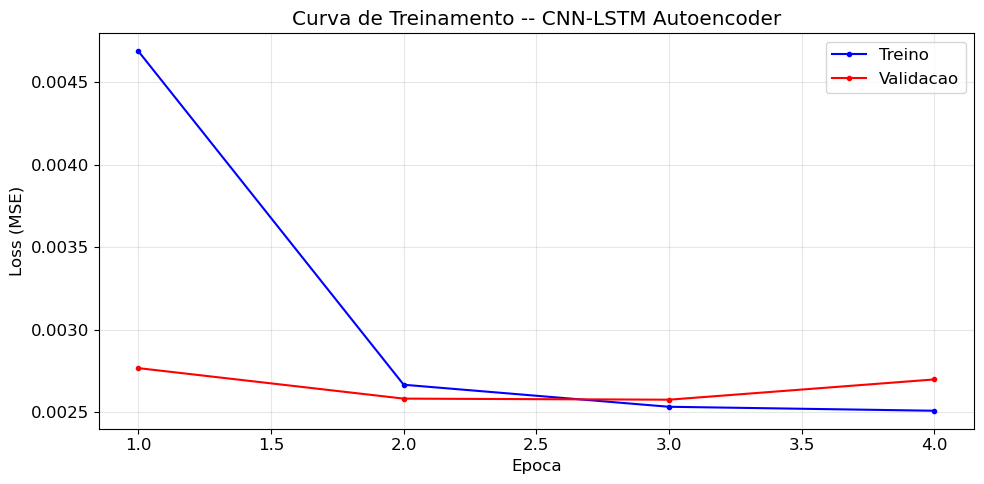

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_losses) + 1), train_losses, 'b-o',
        markersize=3, label='Treino')
ax.plot(range(1, len(val_losses) + 1), val_losses, 'r-o',
        markersize=3, label='Validacao')
ax.set_xlabel('Epoca')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Curva de Treinamento -- CNN-LSTM Autoencoder')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Deteccao de Anomalias

Calculo do erro de reconstrucao (MSE por janela) e definicao dos limiares de deteccao.
Os thresholds sao definidos como o **percentil 95** e o **percentil 99** do erro de
reconstrucao calculado sobre as **janelas saudaveis de validacao**.

Qualquer janela com erro acima do limiar e classificada como falha (anomalia).

In [15]:
def compute_reconstruction_errors(model, dataset, batch_size=256):
    """Calcula o MSE de reconstrucao por janela usando WindowDataset."""
    model.eval()
    errors = []
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0, pin_memory=True)

    with torch.no_grad():
        for batch_x in loader:
            batch_x = batch_x.to(DEVICE)
            output = model(batch_x)
            mse = ((output - batch_x) ** 2).mean(dim=(1, 2))
            errors.extend(mse.cpu().numpy())

    return np.array(errors)


ds_train_h  = WindowDataset(ga_train, eid_tr[healthy_mask_tr],
                            start_tr[healthy_mask_tr], WINDOW_SIZE)
ds_val_h    = WindowDataset(ga_val, eid_va[healthy_mask_va],
                            start_va[healthy_mask_va], WINDOW_SIZE)
ds_val_all  = WindowDataset(ga_val, eid_va, start_va, WINDOW_SIZE)
ds_test_all = WindowDataset(ga_test, eid_te, start_te, WINDOW_SIZE)

errors_train_healthy = compute_reconstruction_errors(model, ds_train_h)
errors_val_healthy   = compute_reconstruction_errors(model, ds_val_h)
errors_val_all       = compute_reconstruction_errors(model, ds_val_all)
errors_test_all      = compute_reconstruction_errors(model, ds_test_all)

print("Erros de reconstrucao (MSE):")
print(f"  Treino (saudavel)    - media: {errors_train_healthy.mean():.6f}, "
      f"std: {errors_train_healthy.std():.6f}, "
      f"max: {errors_train_healthy.max():.6f}")
print(f"  Validacao (saudavel) - media: {errors_val_healthy.mean():.6f}, "
      f"std: {errors_val_healthy.std():.6f}, "
      f"max: {errors_val_healthy.max():.6f}")
print(f"  Validacao (completo) - media: {errors_val_all.mean():.6f}")
print(f"  Teste (completo)     - media: {errors_test_all.mean():.6f}")

Erros de reconstrucao (MSE):
  Treino (saudavel)    - media: 0.002571, std: 0.001470, max: 0.025658
  Validacao (saudavel) - media: 0.002675, std: 0.001716, max: 0.015962
  Validacao (completo) - media: 0.005597
  Teste (completo)     - media: 0.004168


In [16]:
threshold_p95 = float(np.percentile(errors_val_healthy, 95))
threshold_p99 = float(np.percentile(errors_val_healthy, 99))

print("Thresholds (baseados nas janelas saudaveis de validacao):")
print(f"  Percentil 95: {threshold_p95:.6f}")
print(f"  Percentil 99: {threshold_p99:.6f}")

Thresholds (baseados nas janelas saudaveis de validacao):
  Percentil 95: 0.006741
  Percentil 99: 0.008756


## 10. Avaliacao do Modelo

Avaliacao quantitativa no conjunto de teste utilizando ambos os limiares (p95 e p99).
Metricas reportadas: F1-Score, Acuracia, Precisao e Recall.

In [17]:
def evaluate_threshold(errors, y_true, threshold, threshold_name):
    """Avalia metricas de classificacao para um dado threshold."""
    y_pred = (errors > threshold).astype(int)

    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    print(f"\n{'=' * 55}")
    print(f"  Threshold: {threshold_name} = {threshold:.6f}")
    print(f"{'=' * 55}")
    print(f"  Acuracia:   {acc:.4f}")
    print(f"  Precisao:   {prec:.4f}")
    print(f"  Recall:     {rec:.4f}")
    print(f"  F1-Score:   {f1:.4f}")
    print(f"  Predicoes positivas: {y_pred.sum()} / {len(y_pred)}")
    print(f"  VP: {((y_pred == 1) & (y_true == 1)).sum()}  |  "
          f"FP: {((y_pred == 1) & (y_true == 0)).sum()}  |  "
          f"FN: {((y_pred == 0) & (y_true == 1)).sum()}  |  "
          f"VN: {((y_pred == 0) & (y_true == 0)).sum()}")

    return {'threshold': threshold_name, 'value': float(threshold),
            'f1': float(f1), 'accuracy': float(acc),
            'precision': float(prec), 'recall': float(rec)}


print("AVALIACAO NO CONJUNTO DE TESTE")
print("=" * 55)
metrics_p95 = evaluate_threshold(errors_test_all, y_test, threshold_p95,
                                 'Percentil 95')
metrics_p99 = evaluate_threshold(errors_test_all, y_test, threshold_p99,
                                 'Percentil 99')

print("\n\nAVALIACAO NO CONJUNTO DE VALIDACAO")
print("=" * 55)
metrics_val_p95 = evaluate_threshold(errors_val_all, y_val, threshold_p95,
                                     'Percentil 95')
metrics_val_p99 = evaluate_threshold(errors_val_all, y_val, threshold_p99,
                                     'Percentil 99')

AVALIACAO NO CONJUNTO DE TESTE

  Threshold: Percentil 95 = 0.006741
  Acuracia:   0.8379
  Precisao:   0.2572
  Recall:     0.4293
  F1-Score:   0.3217
  Predicoes positivas: 71255 / 476838
  VP: 18329  |  FP: 52926  |  FN: 24364  |  VN: 381219

  Threshold: Percentil 99 = 0.008756
  Acuracia:   0.8476
  Precisao:   0.2148
  Recall:     0.2645
  F1-Score:   0.2371
  Predicoes positivas: 52566 / 476838
  VP: 11293  |  FP: 41273  |  FN: 31400  |  VN: 392872


AVALIACAO NO CONJUNTO DE VALIDACAO

  Threshold: Percentil 95 = 0.006741
  Acuracia:   0.8326
  Precisao:   0.0166
  Recall:     0.2756
  F1-Score:   0.0312
  Predicoes positivas: 77668 / 476577
  VP: 1286  |  FP: 76382  |  FN: 3380  |  VN: 395529

  Threshold: Percentil 99 = 0.008756
  Acuracia:   0.8798
  Precisao:   0.0172
  Recall:     0.2012
  F1-Score:   0.0318
  Predicoes positivas: 54478 / 476577
  VP: 939  |  FP: 53539  |  FN: 3727  |  VN: 418372


## 11. Visualizacoes

Graficos para analise qualitativa dos resultados:
1. Series temporais originais vs reconstruidas (exemplos saudaveis e com anomalia)
2. Erro de reconstrucao ao longo do tempo com marcacao de regioes de falha e thresholds
3. Distribuicao dos erros de reconstrucao (histograma saudavel vs anomalia)

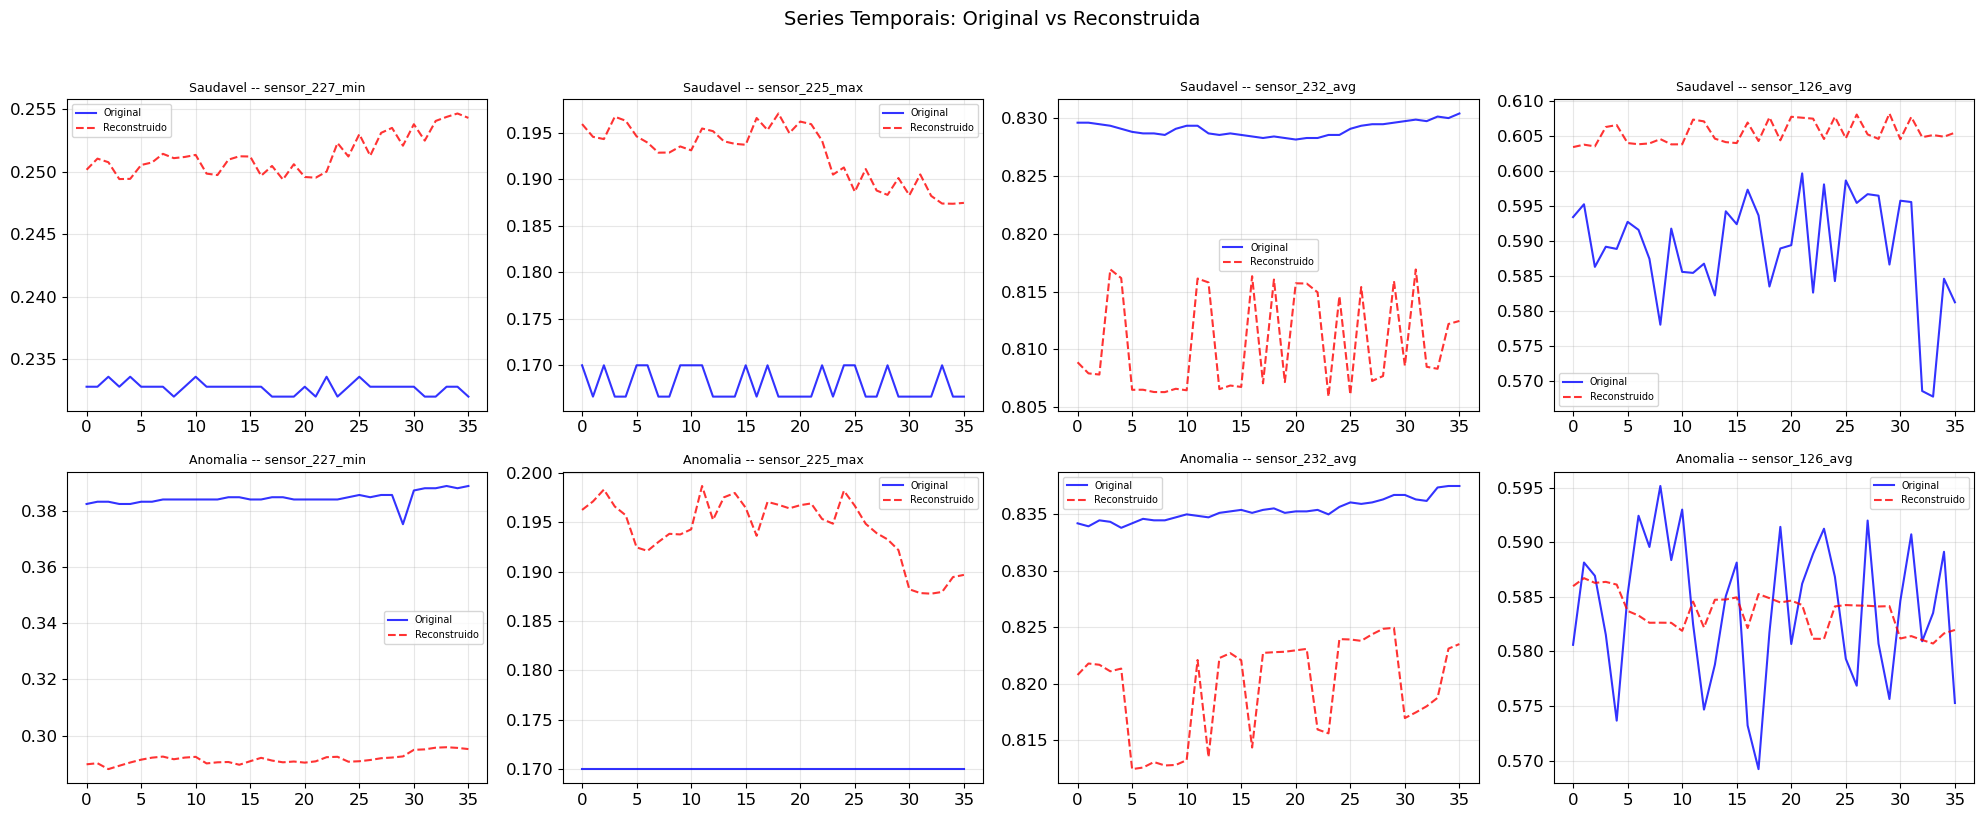

In [18]:
healthy_idx = np.where(y_test == 0)[0]
anomaly_idx = np.where(y_test == 1)[0]

def get_window(ga, eids, starts, ws, idx):
    e, s = int(eids[idx]), int(starts[idx])
    return ga[e][s:s + ws]

model.eval()
with torch.no_grad():
    if len(healthy_idx) > 0:
        w_h = get_window(ga_test, eid_te, start_te, WINDOW_SIZE, healthy_idx[0])
        ex_h = torch.FloatTensor(w_h).unsqueeze(0).to(DEVICE)
        recon_h = model(ex_h).cpu().numpy()[0]
    if len(anomaly_idx) > 0:
        w_a = get_window(ga_test, eid_te, start_te, WINDOW_SIZE, anomaly_idx[0])
        ex_a = torch.FloatTensor(w_a).unsqueeze(0).to(DEVICE)
        recon_a = model(ex_a).cpu().numpy()[0]

n_vis = min(4, n_features)
fig, axes = plt.subplots(2, n_vis, figsize=(5 * n_vis, 8))
if n_vis == 1:
    axes = axes.reshape(2, 1)

ts = range(WINDOW_SIZE)

for j in range(n_vis):
    fname = selected_features[j]

    if len(healthy_idx) > 0:
        axes[0, j].plot(ts, w_h[:, j],
                        'b-', label='Original', alpha=0.8)
        axes[0, j].plot(ts, recon_h[:, j],
                        'r--', label='Reconstruido', alpha=0.8)
        axes[0, j].set_title(f'Saudavel -- {fname}', fontsize=9)
        axes[0, j].legend(fontsize=7)
        axes[0, j].grid(True, alpha=0.3)

    if len(anomaly_idx) > 0:
        axes[1, j].plot(ts, w_a[:, j],
                        'b-', label='Original', alpha=0.8)
        axes[1, j].plot(ts, recon_a[:, j],
                        'r--', label='Reconstruido', alpha=0.8)
        axes[1, j].set_title(f'Anomalia -- {fname}', fontsize=9)
        axes[1, j].legend(fontsize=7)
        axes[1, j].grid(True, alpha=0.3)

plt.suptitle('Series Temporais: Original vs Reconstruida', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

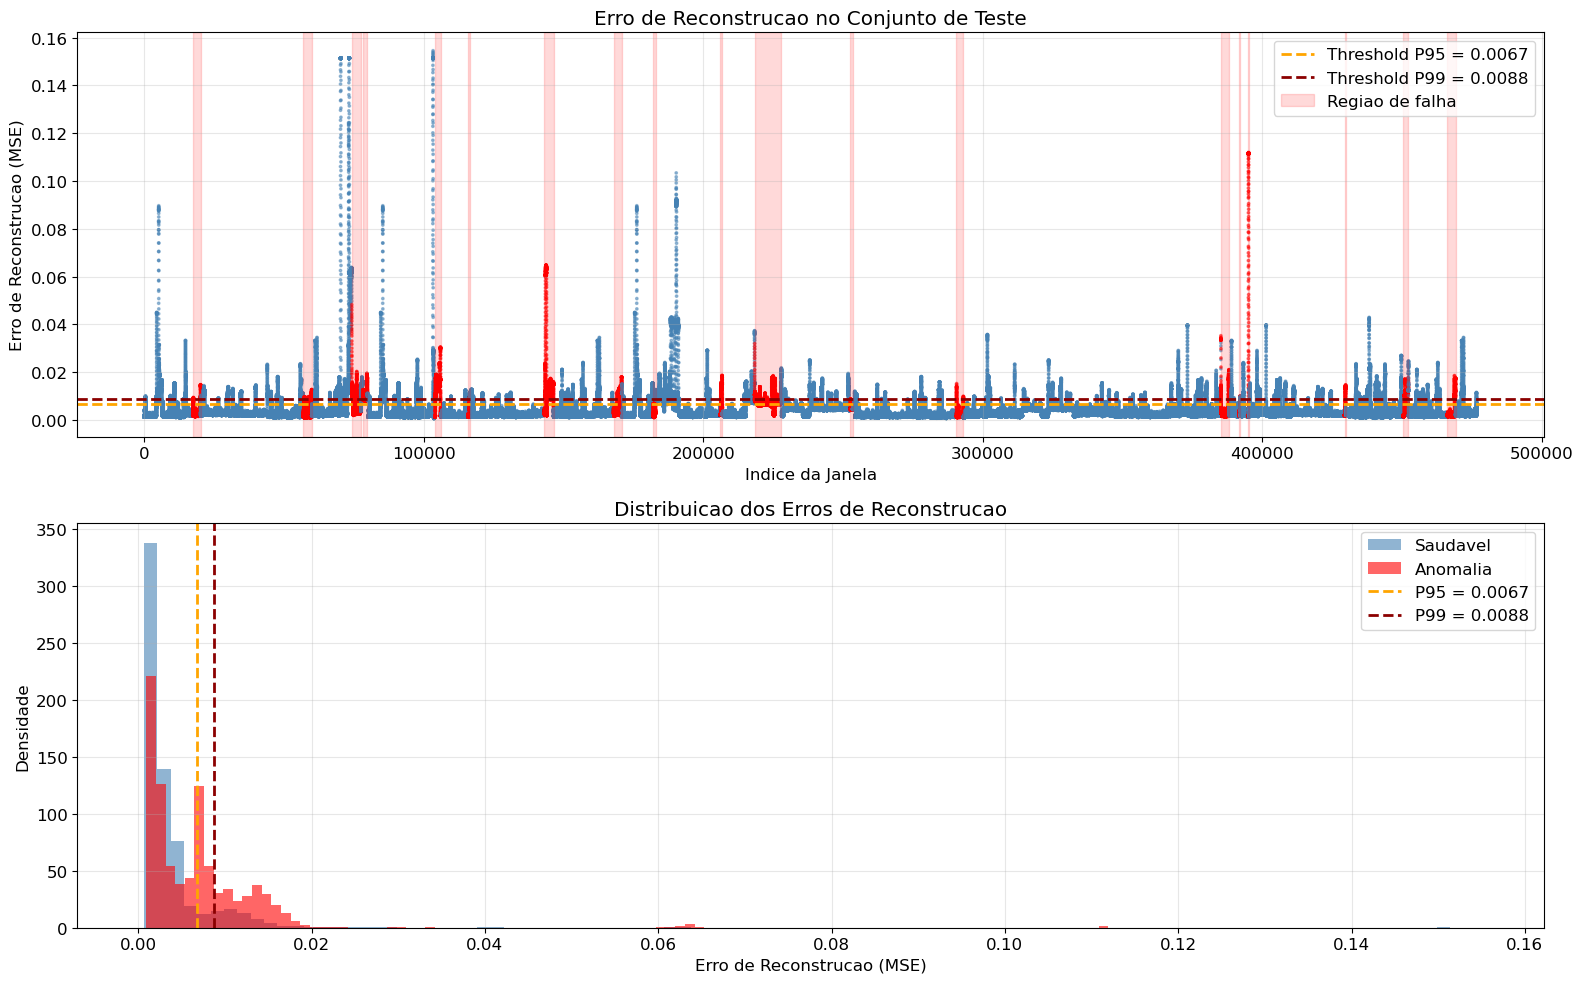

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Erro de reconstrucao no teste ---
ax = axes[0]
test_indices = np.arange(len(errors_test_all))
colors = np.where(y_test == 1, 'red', 'steelblue')
ax.scatter(test_indices, errors_test_all, c=colors, s=3, alpha=0.5)
ax.axhline(y=threshold_p95, color='orange', linestyle='--', linewidth=2,
           label=f'Threshold P95 = {threshold_p95:.4f}')
ax.axhline(y=threshold_p99, color='darkred', linestyle='--', linewidth=2,
           label=f'Threshold P99 = {threshold_p99:.4f}')

fault_starts = np.where(np.diff(np.concatenate(([0], y_test))) == 1)[0]
fault_ends = np.where(np.diff(np.concatenate((y_test, [0]))) == -1)[0] + 1
for i, (s, e) in enumerate(zip(fault_starts, fault_ends)):
    ax.axvspan(s, e, alpha=0.15, color='red',
               label='Regiao de falha' if i == 0 else None)

ax.set_xlabel('Indice da Janela')
ax.set_ylabel('Erro de Reconstrucao (MSE)')
ax.set_title('Erro de Reconstrucao no Conjunto de Teste')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# --- Histograma ---
ax = axes[1]
if y_test.sum() > 0:
    ax.hist(errors_test_all[y_test == 0], bins=100, alpha=0.6,
            label='Saudavel', color='steelblue', density=True)
    ax.hist(errors_test_all[y_test == 1], bins=100, alpha=0.6,
            label='Anomalia', color='red', density=True)
else:
    ax.hist(errors_test_all, bins=100, alpha=0.6,
            label='Todas', color='steelblue', density=True)
ax.axvline(x=threshold_p95, color='orange', linestyle='--', linewidth=2,
           label=f'P95 = {threshold_p95:.4f}')
ax.axvline(x=threshold_p99, color='darkred', linestyle='--', linewidth=2,
           label=f'P99 = {threshold_p99:.4f}')
ax.set_xlabel('Erro de Reconstrucao (MSE)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuicao dos Erros de Reconstrucao')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

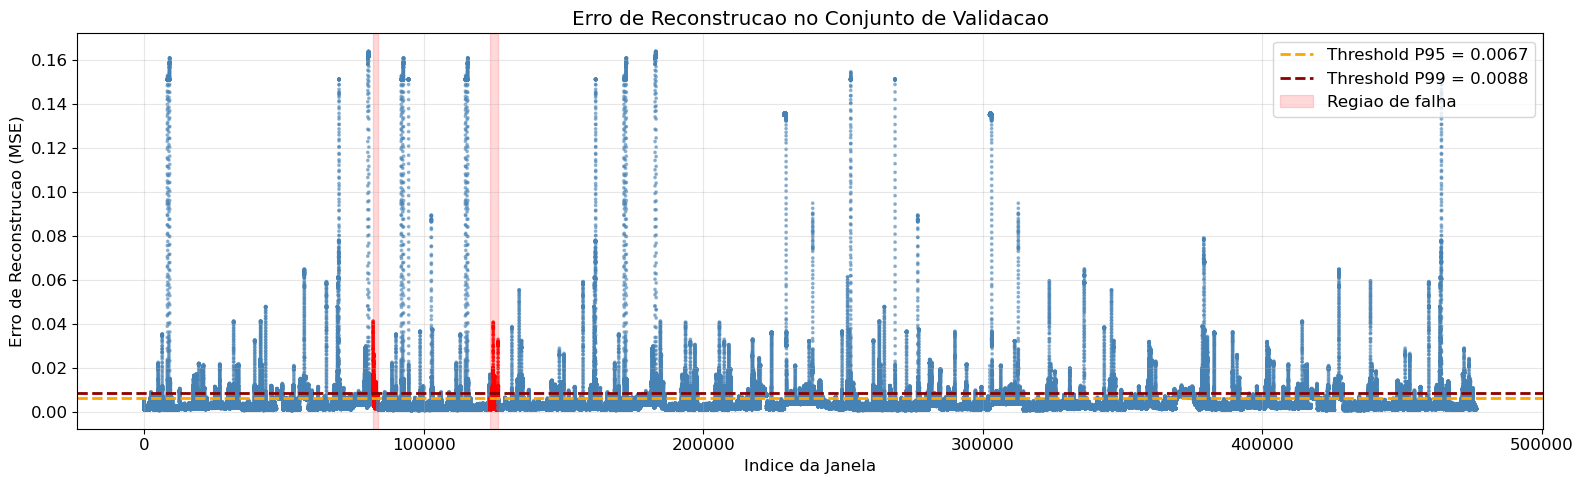

In [20]:
fig, ax = plt.subplots(figsize=(16, 5))

val_indices = np.arange(len(errors_val_all))
colors_val = np.where(y_val == 1, 'red', 'steelblue')
ax.scatter(val_indices, errors_val_all, c=colors_val, s=3, alpha=0.5)
ax.axhline(y=threshold_p95, color='orange', linestyle='--', linewidth=2,
           label=f'Threshold P95 = {threshold_p95:.4f}')
ax.axhline(y=threshold_p99, color='darkred', linestyle='--', linewidth=2,
           label=f'Threshold P99 = {threshold_p99:.4f}')

fault_starts_v = np.where(np.diff(np.concatenate(([0], y_val))) == 1)[0]
fault_ends_v = np.where(np.diff(np.concatenate((y_val, [0]))) == -1)[0] + 1
for i, (s, e) in enumerate(zip(fault_starts_v, fault_ends_v)):
    ax.axvspan(s, e, alpha=0.15, color='red',
               label='Regiao de falha' if i == 0 else None)

ax.set_xlabel('Indice da Janela')
ax.set_ylabel('Erro de Reconstrucao (MSE)')
ax.set_title('Erro de Reconstrucao no Conjunto de Validacao')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Salvamento de Artefatos

Salvamento do modelo treinado, scaler de normalizacao, lista de features selecionadas
e thresholds para uso posterior em producao ou analises futuras.

In [21]:
model_path = os.path.join(OUTPUT_DIR, 'modelo_cnn_lstm_autoencoder.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'n_features': n_features,
    'timesteps': WINDOW_SIZE,
    'architecture': 'CNNLSTMAutoencoder',
    'best_val_loss': best_val_loss,
    'train_losses': train_losses,
    'val_losses': val_losses,
}, model_path)
print(f"Modelo salvo: {model_path}")

scaler_path = os.path.join(OUTPUT_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler salvo: {scaler_path}")

features_path = os.path.join(OUTPUT_DIR, 'features_selecionadas.json')
with open(features_path, 'w') as f:
    json.dump({
        'selected_features': selected_features,
        'n_original_features': len(sensor_cols),
        'n_selected_features': len(selected_features),
        'selection_method': 'XGBoost top 30%',
    }, f, indent=2, ensure_ascii=False)
print(f"Features salvas: {features_path}")

thresholds_path = os.path.join(OUTPUT_DIR, 'thresholds.json')
with open(thresholds_path, 'w') as f:
    json.dump({
        'threshold_p95': threshold_p95,
        'threshold_p99': threshold_p99,
        'computed_on': 'janelas saudaveis de validacao',
        'metrics_teste_p95': metrics_p95,
        'metrics_teste_p99': metrics_p99,
    }, f, indent=2, ensure_ascii=False)
print(f"Thresholds salvos: {thresholds_path}")

print(f"\nArtefatos salvos no diretorio: {os.path.abspath(OUTPUT_DIR)}/")

Modelo salvo: artefatos\modelo_cnn_lstm_autoencoder.pth
Scaler salvo: artefatos\scaler.pkl
Features salvas: artefatos\features_selecionadas.json
Thresholds salvos: artefatos\thresholds.json

Artefatos salvos no diretorio: c:\Users\tibis\OneDrive\Desktop\IC_WIND_THIAGO\artefatos/


## Conclusao

Este notebook implementou um pipeline completo de deteccao de anomalias em turbinas
eolicas utilizando dados SCADA do Wind Farm C:

1. **Pre-processamento**: forward fill de valores ausentes e normalizacao Min-Max
2. **Selecao de features**: XGBoost identificou as top 30% features mais relevantes
3. **Modelo**: CNN-LSTM Autoencoder treinado exclusivamente com dados saudaveis
4. **Deteccao**: thresholds nos percentis 95 e 99 do erro de reconstrucao
5. **Avaliacao**: metricas de classificacao (F1, Acuracia, Precisao, Recall)

Todos os artefatos (modelo, scaler, features, thresholds) foram salvos para
reproducibilidade e uso em producao.